# 202235203 고수호
# **4week - titanic.csv 데이터에 대한 Regression**
데이터를 '**Feature Selection** 유/무', '**결측치** 대체/제거' 등의 전략을 통해 나누어 전략간의 **평균제곱근오차(mse)** 평가.

# **# 데이터 세트 불러오기**
`import pandas as pd` : 데이터를 표(Table) 형태로 다루기 위한 **Pandas** 라이브러리.  
`import numpy as np` : 수치 계산 및 행렬 연산을 위한 **NumPy** 라이브러리.  
`import seaborn as sns` : 데이터를 읽기 쉽게 시각화하는 **Seaborn** 라이브러리.  
`path = '/content/drive/MyDrive/Colab Notebooks/4week/titanic.csv'` : 데이터 파일이 저장된 경로를 문자열 변수 '**path**'에 저장.  
`df = pd.read_csv(path)` : 읽어온 데이터는 데이터프레임 형태로 변수 '**df**'에 저장.  


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = '/content/drive/MyDrive/Colab Notebooks/4week/titanic.csv'
df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# **# 라벨 인코딩과 상관관계 확인**
```
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
```
* **LabelEncoder** : 문자열 데이터를 모델이 이해할 수 있는 숫자로 변환하는 도구.
* **df_encoded** : 원본 데이터를 보존하기 위해 복사본 생성.

```
le = LabelEncoder()
for col in df_encoded.columns:
  if df_encoded[col].dtype == 'object':
      df_encoded[col] = le.fit_transform(df_encoded[col])
```
* **역할** : 데이터의 모든 Column을 검사하여 데이터 타입이 **object(문자열)** 인 경우에만 숫자로 변환.
* **예시** :
  * Sex : female -> 0, male -> 1
  * Embarked : C -> 0, Q -> 1, S -> 2
```
df_corr = df_encoded.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
```
* **corr()** : 모든 숫자형 변수 쌍 간의 **피어슨 상관계수**를 계산하여 행렬 형태로 변환.
* **figsize=(10,10)** : 그래프의 크기를 가로세로 10인치로 설정.
* **sns.set(font_scale=0.8)** : 글자 크기를 0.8로 설정.
* **sns.heatmap(...)** : 상관계수 행렬을 색상으로 시각화.
  * **annot=True** : 각 칸에 실제 상관계수 숫자를 표시.
  * **cbar=False** : 우측의 수치별 색상 막대를 제거.

<Axes: >

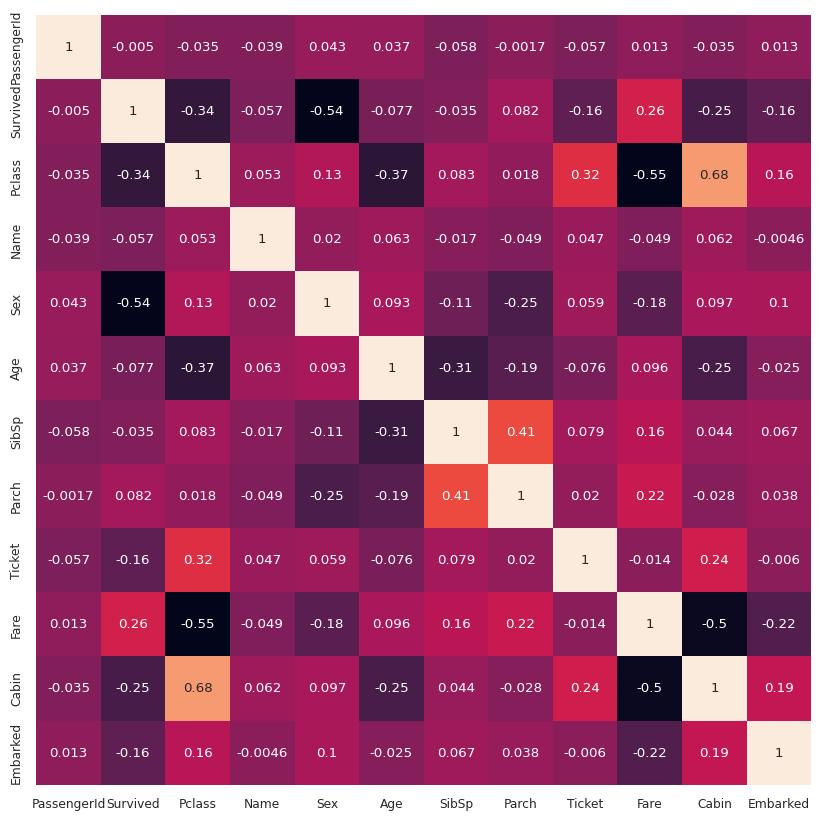

In [82]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.columns:
  if df_encoded[col].dtype == 'object':
      df_encoded[col] = le.fit_transform(df_encoded[col])

df_corr = df_encoded.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 결측치 확인**
`df_encoded.isnull().sum()`
* **isnull()** : 각 데이터 칸이 비어있는지 채워져 있는지 판별.
* **.sum()** : 채워져 있는 칸의 개수를 합산.

In [83]:
df_encoded.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **# 결측치 처리 전략(대체)**
```
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mean = df_encoded.copy()
df_median = df_encoded.copy()
df_most = df_encoded.copy()
df_iter = df_encoded.copy()
```
* **IterativeImputer** : 다른 변수들간의 관계를 계산하여 빈값을 예측하는 도구.
* **df_mean** : 결측치를 평균값으로 채운 df.
* **df_median** : 결측치를 중앙값으로 채운 df.
* **df_most** : 결측치를 최빈값으로 채운 df.
* **df_iter** : 결측치를 컬럼들간의 특징을 통해 예측하여 채운 df.

In [84]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mean = df_encoded.copy()
df_median = df_encoded.copy()
df_most = df_encoded.copy()
df_iter = df_encoded.copy()

df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean()) # Age의 결측치를 평균값으로
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median()) # Age의 결측치를 중앙값으로
df_most['Age'] = df_most['Age'].fillna(df_median['Age'].median()) # Age의 결측치를 최빈값으로

it_imp = IterativeImputer(random_state=0) # 결측치를 예측해서 채워줄 인공지능 도구(it_imp) 준비
df_iter[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']] = it_imp.fit_transform( # Age의 결측치를 추정값으로(Age와 다른 컬럼들의 관계를 통한 추측)
    df_iter[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']] # IterativeImputer는 숫자 데이터만 이해 가능하기에 숫자형 컬럼만 모아서 처리
)

# **# 결측치 처리 전략(제거)**
```
df_encoded = df_encoded.dropna()
```
* **dropna()** : 데이터프레임의 모든 행을 검사하여 **결측치(NaN)**가 하나라도 포함된 행이 있다면 해당 행 전체를 삭제.


In [85]:
df_encoded= df_encoded.dropna()
df_encoded.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **# 결측치 처리 전략에 따른 데이터 전처리와 Feature Selection**
`.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked']`

**타겟 변수** : **'Survived'**  
**PassengerId** : 상관계수(0.013)  
**Name** : 상관계수(0.049), 문자열데이터  
**Ticket** : 상관계수(0.014), 문자열데이터  
**Cabin** : 대부분의 값이 결측치, 문자열데이터  
**Embarked** : 상관계수(0.22), 문자열데이터  

In [86]:
y = df_encoded['Fare']
y_fs = df_encoded['Fare']
y_mean = df_mean['Fare']
y_median = df_median['Fare']
y_most = df_most['Fare']
y_iter = df_iter['Fare']

X = df_encoded.drop(['Fare'],axis=1)
X_fs = df_encoded.drop(['Fare','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_mean = df_mean.drop(['Fare','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_median = df_median.drop(['Fare','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_most = df_most.drop(['Fare','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_iter = df_iter.drop(['Fare','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)

# **# 데이터셋 분리 (Training & Test Set)**
`from sklearn.model_selection import train_test_split` : 데이터를 나누기 위한 사이킷런의 함수.  
`test_size=0.25` : 전체 데이터의 **25%** 를 평가용(Test)으로, **75%** 를 학습용(Train)으로 설정.  
`random_state=0` : 실행할 때마다 동일한 결과가 나오도록 난수 시드 고정.

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs,test_size=0.25,random_state=0)
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(X_mean, y_mean,test_size=0.25,random_state=0)
X_train_median, X_test_median, y_train_median, y_test_median = train_test_split(X_median, y_median,test_size=0.25,random_state=0)
X_train_most, X_test_most, y_train_most, y_test_most = train_test_split(X_most, y_most,test_size=0.25,random_state=0)
X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(X_iter, y_iter,test_size=0.25,random_state=0)

# **# 전략별 학습 및 평가 1 - 기본 DF(df)**
**Feature Selection을 하지 않고 결측치를 모두 제거한 DF**   

**Linear Regression mse** : 1025  
**Decision Tree mse** : 801  
**Random Forest mse** : 670    
**kNN mse** : 1941

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

model_lr = LinearRegression()
model_dt = DecisionTreeRegressor()
model_rf = RandomForestRegressor()
knn = KNeighborsRegressor(n_neighbors=6)

model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

ly_preds = model_lr.predict(X_test)
dy_preds = model_dt.predict(X_test)
ry_preds = model_rf.predict(X_test)
y_pred = knn.predict(X_test)

print ("\n--- Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차(mse): ', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차(mse): ', mse(ly_preds, y_test))

print ("\n--- Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds, y_test))

print ("\n--- Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds, y_test))

print ("\n--- kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred, y_test))


--- Linear Regression ---
평균제곱근오차(mse):  1025.8034076678898
평균제곱근오차(mse):  1025.8034076678898
평균제곱근오차(mse):  1025.8034076678898

--- Decision Tree ---
평균제곱근오차(mse):  817.3720432127375

--- Random Forest ---
평균제곱근오차(mse):  642.4221348388157

--- kNN ---
평균제곱근오차(mse):  1941.8492413773201


# **# 전략별 학습 및 평가 2 - Feature Selection DF(df_fs)**
**Feature Selection을 하고 결측치를 모두 제거한 DF**  
**Logistic Regression mse** : 993    
**Decision Tree mse** : 1742  
**Random Forest mse** : 1097   
**kNN mse** : 2105  

In [89]:
model_lr.fit(X_train_fs, y_train_fs)
model_dt.fit(X_train_fs, y_train_fs)
model_rf.fit(X_train_fs, y_train_fs)
knn.fit(X_train_fs, y_train_fs)

ly_preds_fs = model_lr.predict(X_test_fs)
dy_preds_fs = model_dt.predict(X_test_fs)
ry_preds_fs = model_rf.predict(X_test_fs)
y_pred_fs = knn.predict(X_test_fs)

print ("\n--- [FS] Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds_fs, y_test_fs))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차(mse): ', mse_np(ly_preds_fs, y_test_fs))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차(mse): ', mse(ly_preds_fs, y_test_fs))

print ("\n--- [FS] Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds_fs, y_test_fs))

print ("\n--- [FS] Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds_fs, y_test_fs))

print ("\n--- [FS] kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred_fs, y_test_fs))


--- [FS] Linear Regression ---
평균제곱근오차(mse):  993.7994099720211
평균제곱근오차(mse):  993.7994099720211
평균제곱근오차(mse):  993.7994099720212

--- [FS] Decision Tree ---
평균제곱근오차(mse):  1280.9722043244549

--- [FS] Random Forest ---
평균제곱근오차(mse):  1035.4738662868904

--- [FS] kNN ---
평균제곱근오차(mse):  2105.1849573098757


# **# 전략별 학습 및 평가 3 - 평균값 DF(df_mean)**
**Feature Selection을 하고 결측치를 평군값으로 대체한 DF**  
**Logistic Regression mse** : 1156   
**Decision Tree mse** : 1808   
**Random Forest mse** : 987  
**kNN mse** : 1763    

In [90]:
model_lr.fit(X_train_mean, y_train_mean)
model_dt.fit(X_train_mean, y_train_mean)
model_rf.fit(X_train_mean, y_train_mean)
knn.fit(X_train_mean, y_train_mean)

ly_preds_mean = model_lr.predict(X_test_mean)
dy_preds_mean = model_dt.predict(X_test_mean)
ry_preds_mean = model_rf.predict(X_test_mean)
y_pred_mean = knn.predict(X_test_mean)

print ("\n--- [MEAN] Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds_mean, y_test_mean))

print('평균제곱근오차(mse): ', mse_np(ly_preds_mean, y_test_mean))
print('평균제곱근오차(mse): ', mse(ly_preds_mean, y_test_mean))

print ("\n--- [MEAN] Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds_mean, y_test_mean))

print ("\n--- [MEAN] Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds_mean, y_test_mean))

print ("\n--- [MEAN] kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred_mean, y_test_mean))


--- [MEAN] Linear Regression ---
평균제곱근오차(mse):  1156.6858118041578
평균제곱근오차(mse):  1156.6858118041578
평균제곱근오차(mse):  1156.6858118041582

--- [MEAN] Decision Tree ---
평균제곱근오차(mse):  1806.7074118111243

--- [MEAN] Random Forest ---
평균제곱근오차(mse):  1044.7788041241347

--- [MEAN] kNN ---
평균제곱근오차(mse):  1763.0950926462806


# **# 전략별 학습 및 평가 4 - 중앙값 DF(df_median)**
**Feature Selection을 하고 결측치를 중앙값으로 대체한 DF**  
**Logistic Regression mse** : 1156   
**Decision Tree mse** : 1825   
**Random Forest mse** : 976  
**kNN mse** : 1622  

In [91]:
model_lr.fit(X_train_median, y_train_median)
model_dt.fit(X_train_median, y_train_median)
model_rf.fit(X_train_median, y_train_median)
knn.fit(X_train_median, y_train_median)

ly_preds_median = model_lr.predict(X_test_median)
dy_preds_median = model_dt.predict(X_test_median)
ry_preds_median = model_rf.predict(X_test_median)
y_pred_median = knn.predict(X_test_median)

print ("\n--- [MEDIAN] Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds_median, y_test_median))

print('평균제곱근오차(mse): ', mse_np(ly_preds_median, y_test_median))
print('평균제곱근오차(mse): ', mse(ly_preds_median, y_test_median))

print ("\n--- [MEDIAN] Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds_median, y_test_median))

print ("\n--- [MEDIAN] Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds_median, y_test_median))

print ("\n--- [MEDIAN] kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred_median, y_test_median))


--- [MEDIAN] Linear Regression ---
평균제곱근오차(mse):  1156.474390936583
평균제곱근오차(mse):  1156.474390936583
평균제곱근오차(mse):  1156.4743909365827

--- [MEDIAN] Decision Tree ---
평균제곱근오차(mse):  1837.8568691302858

--- [MEDIAN] Random Forest ---
평균제곱근오차(mse):  998.755752741247

--- [MEDIAN] kNN ---
평균제곱근오차(mse):  1622.5040090692678


# **# 전략별 학습 및 평가 5 - 최빈값 DF(df_most)**
**Feature Selection을 하고 결측치를 최빈값으로 대체한 DF**  
**Logistic Regression mse** : 1156   
**Decision Tree mse** : 1825   
**Random Forest mse** : 1053  
**kNN mse** : 1622  

In [92]:
model_lr.fit(X_train_most, y_train_most)
model_dt.fit(X_train_most, y_train_most)
model_rf.fit(X_train_most, y_train_most)
knn.fit(X_train_most, y_train_most)

ly_preds_most = model_lr.predict(X_test_most)
dy_preds_most = model_dt.predict(X_test_most)
ry_preds_most = model_rf.predict(X_test_most)
y_pred_most = knn.predict(X_test_most)

print ("\n--- [MOST] Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds_most, y_test_most))

print('평균제곱근오차(mse): ', mse_np(ly_preds_most, y_test_most))
print('평균제곱근오차(mse): ', mse(ly_preds_most, y_test_most))

print ("\n--- [MOST] Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds_most, y_test_most))

print ("\n--- [MOST] Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds_most, y_test_most))

print ("\n--- [MOST] kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred_most, y_test_most))


--- [MOST] Linear Regression ---
평균제곱근오차(mse):  1156.474390936583
평균제곱근오차(mse):  1156.474390936583
평균제곱근오차(mse):  1156.4743909365827

--- [MOST] Decision Tree ---
평균제곱근오차(mse):  1809.1825364577744

--- [MOST] Random Forest ---
평균제곱근오차(mse):  1048.9547390626642

--- [MOST] kNN ---
평균제곱근오차(mse):  1622.5040090692678


# **# 전략별 학습 및 평가 6 - 추청값 DF(df_iter)**
**Feature Selection을 하고 결측치를 추청값으로 대체한 DF**  
**Logistic Regression mse** : 1152   
**Decision Tree mse** : 1341   
**Random Forest mse** : 1017  
**kNN mse** : 1428  

In [93]:
model_lr.fit(X_train_iter, y_train_iter)
model_dt.fit(X_train_iter, y_train_iter)
model_rf.fit(X_train_iter, y_train_iter)
knn.fit(X_train_iter, y_train_iter)

ly_preds_iter = model_lr.predict(X_test_iter)
dy_preds_iter = model_dt.predict(X_test_iter)
ry_preds_iter = model_rf.predict(X_test_iter)
y_pred_iter = knn.predict(X_test_iter)

print ("\n--- [ITER] Linear Regression ---")
print('평균제곱근오차(mse): ', mean_squared_error(ly_preds_iter, y_test_iter))

print('평균제곱근오차(mse): ', mse_np(ly_preds_iter, y_test_iter))
print('평균제곱근오차(mse): ', mse(ly_preds_iter, y_test_iter))

print ("\n--- [ITER] Decision Tree ---")
print('평균제곱근오차(mse): ', mean_squared_error(dy_preds_iter, y_test_iter))

print ("\n--- [ITER] Random Forest ---")
print('평균제곱근오차(mse): ', mean_squared_error(ry_preds_iter, y_test_iter))

print ("\n--- [ITER] kNN ---")
print('평균제곱근오차(mse): ', mean_squared_error(y_pred_iter, y_test_iter))


--- [ITER] Linear Regression ---
평균제곱근오차(mse):  1152.14304847046
평균제곱근오차(mse):  1152.14304847046
평균제곱근오차(mse):  1152.1430484704601

--- [ITER] Decision Tree ---
평균제곱근오차(mse):  1337.654733583425

--- [ITER] Random Forest ---
평균제곱근오차(mse):  984.2232788869975

--- [ITER] kNN ---
평균제곱근오차(mse):  1428.346113329467


# **# 전략별 시각화 1 - 기본 DF(df)**

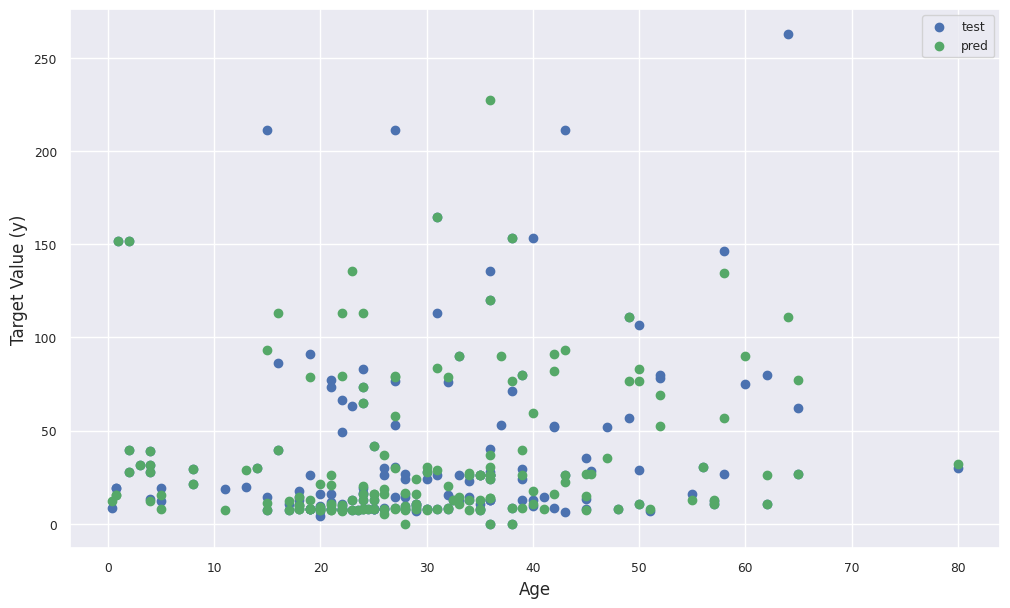

In [94]:
plt.figure(figsize=(12,7))

plt.scatter(X_test['Age'], y_test, label='test')
plt.scatter(X_test['Age'], dy_preds, c='g', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()


# **# 전략별 시각화 2 - Feature Selection DF(df_fs)**

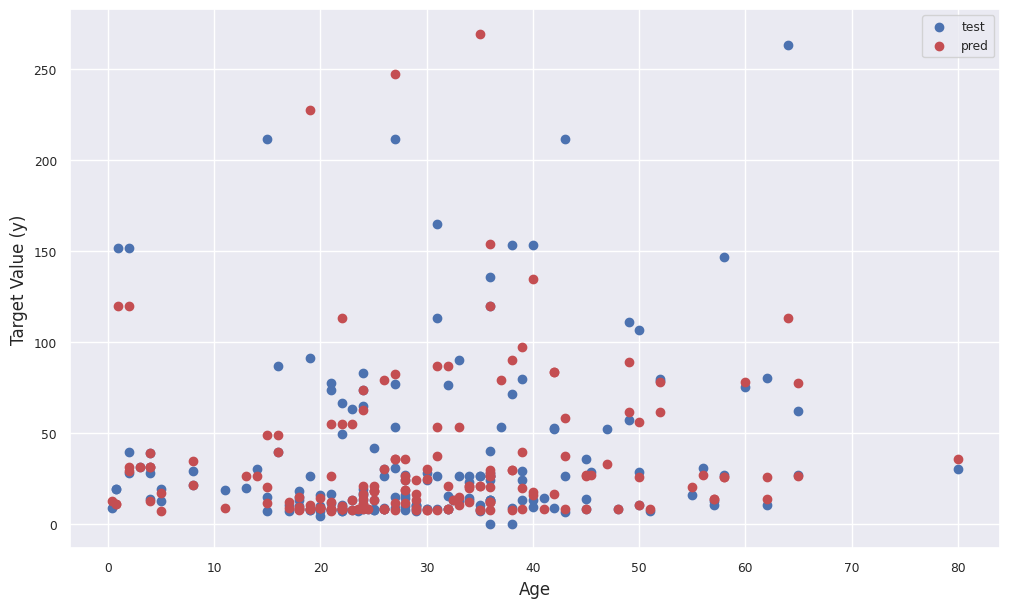

In [95]:
plt.figure(figsize=(12,7))

plt.scatter(X_test_fs['Age'], y_test_fs, label='test')
plt.scatter(X_test_fs['Age'], dy_preds_fs, c='r', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()

# **# 전략별 시각화 3 - 평균값 DF(df_mean)**

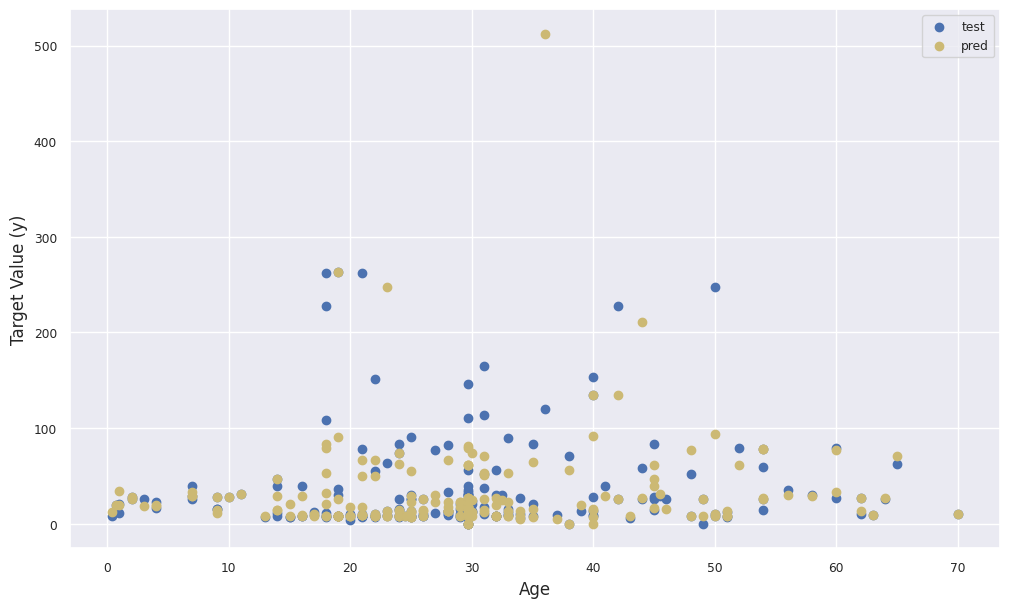

In [96]:
plt.figure(figsize=(12,7))

plt.scatter(X_test_mean['Age'], y_test_mean, label='test')
plt.scatter(X_test_mean['Age'], dy_preds_mean, c='y', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()

# **# 전략별 시각화 4 - 중앙값 DF(df_median)**

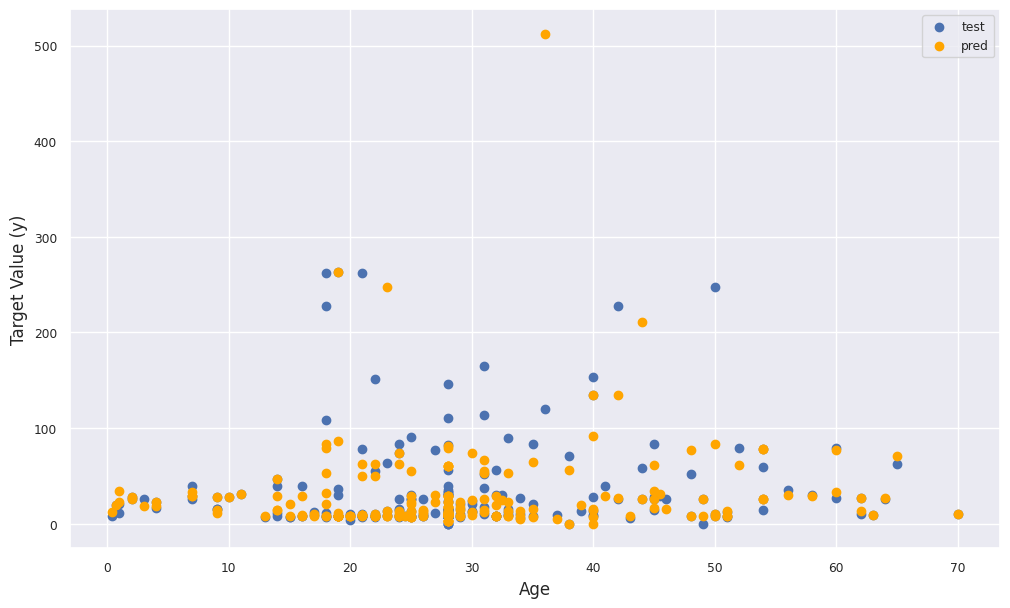

In [97]:
plt.figure(figsize=(12,7))

plt.scatter(X_test_median['Age'], y_test_median, label='test')
plt.scatter(X_test_median['Age'], dy_preds_median, c='orange', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()

# **# 전략별 시각화 5 - 최빈값 DF(df_most)**

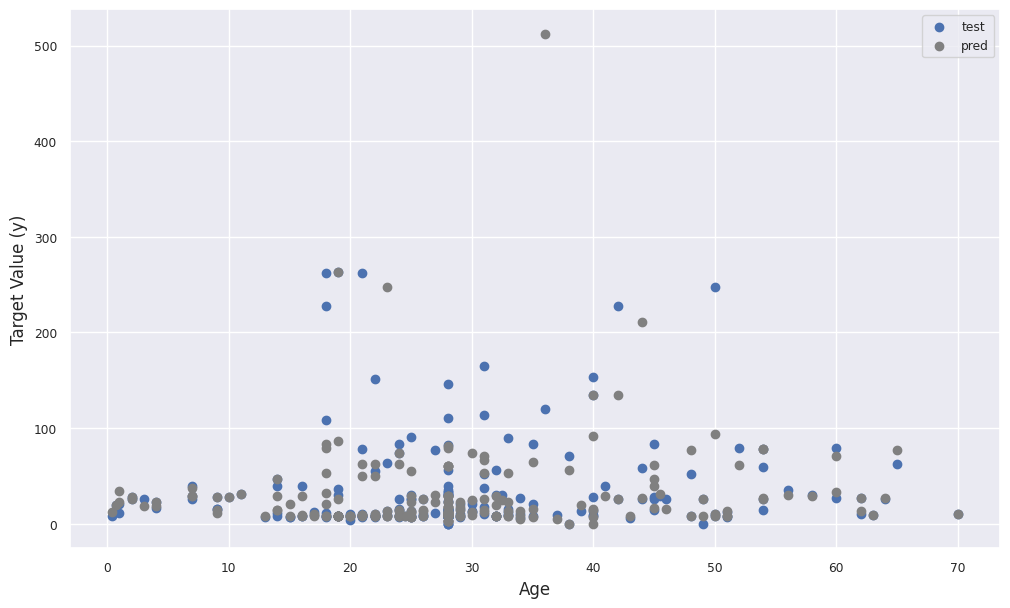

In [98]:
plt.figure(figsize=(12,7))

plt.scatter(X_test_most['Age'], y_test_most, label='test')
plt.scatter(X_test_most['Age'], dy_preds_most, c='gray', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()

# **# 전략별 시각화 6 - 추정값 DF(df_iter)**

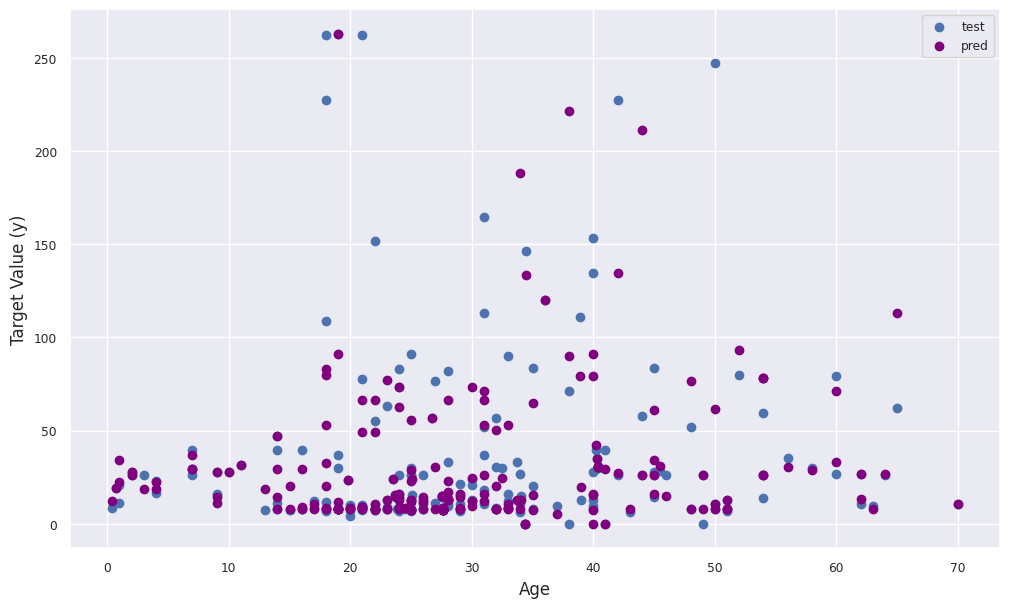

In [99]:
plt.figure(figsize=(12,7))

plt.scatter(X_test_iter['Age'], y_test_iter, label='test')
plt.scatter(X_test_iter['Age'], dy_preds_iter, c='purple', label='pred')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.legend()
plt.show()